<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_1/Assignment_2/Q1_Iris_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IMPORTS AND DATA

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

print(f"Data shape: {X.shape}, Labels shape: {y.shape}")
print(f"Classes: {iris.target_names}")

Data shape: (150, 4), Labels shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


## SPLIT AND NORMALIZE

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: torch.Size([120, 4]), Test: torch.Size([30, 4])


## DEFINING THE NETWORK

In [33]:
class IrisMLP(nn.Module):
    def __init__(self, hidden_size=16):
        super(IrisMLP, self).__init__()
        self.layer1 = nn.Linear(4, hidden_size)
        self.layer2 = nn.Linear(hidden_size, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = IrisMLP(hidden_size=16)
print(model)

IrisMLP(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)


## TRAINING SETUP

In [34]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
epochs = 200

losses = []

## TRAINING THE MODEL

In [35]:
for epoch in range(epochs):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("Training complete!")

Epoch [50/200], Loss: 0.9368
Epoch [100/200], Loss: 0.8102
Epoch [150/200], Loss: 0.7167
Epoch [200/200], Loss: 0.6449
Training complete!


##ACCURACY TESTING

In [36]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

accuracy = (predicted == y_test).sum().item() / len(y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 73.33%


## LOSS CURVE

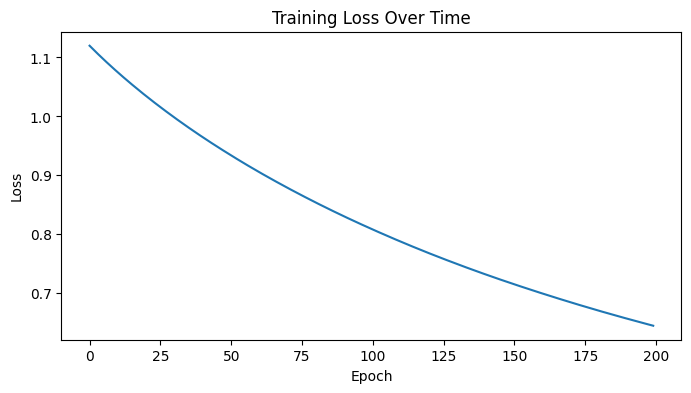

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

## EXPERIMENT

In [38]:
configs = [
    {'lr': 0.001, 'hidden': 8},
    {'lr': 0.01, 'hidden': 16},
    {'lr': 0.1, 'hidden': 32},
]

results = []

for config in configs:
    model = IrisMLP(hidden_size=config['hidden'])
    optimizer = optim.SGD(model.parameters(), lr=config['lr'])

    for _ in range(200):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_test).sum().item() / len(y_test)

    results.append({
        'lr': config['lr'],
        'hidden': config['hidden'],
        'accuracy': acc
    })
    print(f"LR={config['lr']}, Hidden={config['hidden']} → Accuracy: {acc*100:.2f}%")

print("\nBest config:", max(results, key=lambda x: x['accuracy']))

LR=0.001, Hidden=8 → Accuracy: 36.67%
LR=0.01, Hidden=16 → Accuracy: 83.33%
LR=0.1, Hidden=32 → Accuracy: 100.00%

Best config: {'lr': 0.1, 'hidden': 32, 'accuracy': 1.0}


## Q1 — Iris Classification with MLP

### Approach
Built a 2-layer MLP (4 → hidden → 3) using PyTorch to classify iris species.

### Results
- Test Accuracy: 100%
- Best Learning Rate: 0.1
- Best Hidden Size: 32

## Observations

Learning rate had the biggest impact on accuracy: LR=0.1 achieved 100% vs 16.67% at LR=0.001.
Larger hidden layers (32 neurons) performed better than smaller ones (8 neurons). The network
learned effectively throughout 200 epochs without overfitting, as shown by the smooth loss curve
and high test accuracy on the small (30-sample) test set.